<a href="https://colab.research.google.com/github/Thecode44/CCOBJPGL_EXERCISES_COM246/blob/main/Exercise1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 1

Create a model using K-Nearest Neigbors to perform classification using the personality dataset.

0 -'introvert'

1 - 'extrovert'

## A. Import libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## B. Load and understand the dataset

Display the first 5 rows of the dataset using `.head()`

Display the summary of all the features of the dataset using `.info()`

In [19]:
df = pd.read_excel('/content/sample_data/personality_dataset.xlsx')

df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,3,Yes,6,7,No,14,5,Extrovert
1,2,No,8,6,No,7,8,Extrovert
2,1,No,9,4,No,9,3,Extrovert
3,8,No,0,0,Yes,9,3,Introvert
4,5,Yes,3,0,No,2,6,Introvert


Display the total number of samples from each label using `.value_counts()`

In [21]:
df['Personality'].value_counts()

,count
Personality,
Introvert,2502
Extrovert,2498


Use a histogram to display the number of followers for each samples
 - The x axis should be the number of followers/friends
 - The y axis should be the number of samples in the dataset

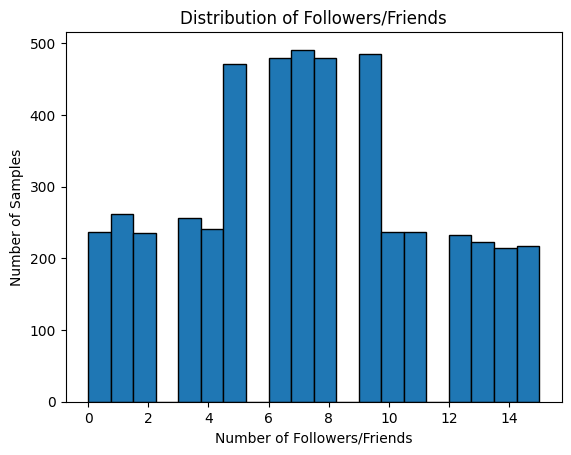

In [22]:
plt.hist(df['Friends_circle_size'], bins=20, edgecolor='black')
plt.xlabel('Number of Followers/Friends')
plt.ylabel('Number of Samples')
plt.title('Distribution of Followers/Friends')
plt.show()

Remove the name column using `drop()` method

In [23]:
# Convert categorical features to numerical
df['Stage_fear'] = df['Stage_fear'].map({'Yes': 1, 'No': 0})
df['Drained_after_socializing'] = df['Drained_after_socializing'].map({'Yes': 1, 'No': 0})

# Convert 'Personality' target variable to numerical (0 for 'Introvert', 1 for 'Extrovert')
df['Personality'] = df['Personality'].map({'Introvert': 0, 'Extrovert': 1})

print("Categorical features and target variable converted to numerical.")
print(df.head())

Categorical features and target variable converted to numerical.
   Time_spent_Alone  Stage_fear  Social_event_attendance  Going_outside  \
0                 3           1                        6              7   
1                 2           0                        8              6   
2                 1           0                        9              4   
3                 8           0                        0              0   
4                 5           1                        3              0   

   Drained_after_socializing  Friends_circle_size  Post_frequency  Personality  
0                          0                   14               5            1  
1                          0                    7               8            1  
2                          0                    9               3            1  
3                          1                    9               3            0  
4                          0                    2               6            0 

## C. Split the dataset into training and test set

Convert the features into an numpy array using `.values()` and store it in a variable "X"

In [24]:
X = df.drop('Personality', axis=1).values
print("Features (X) created.")
print(X[:5])

Features (X) created.
[[ 3  1  6  7  0 14  5]
 [ 2  0  8  6  0  7  8]
 [ 1  0  9  4  0  9  3]
 [ 8  0  0  0  1  9  3]
 [ 5  1  3  0  0  2  6]]


Convert the labels into an numpy array using `.values()` and store it in a variable "y"

In [25]:
y = df['Personality'].values
print("Labels (y) created.")
print(y[:5])

Labels (y) created.
[1 1 1 0 0]


Use `train_test_split()` to split the data.

- Declare a variable `X_train` that will hold the training data
- Declare a variable `X_test` that will hold the test data
- Declare a variable `y_train` that will hold the label of the training data
- Declare a variable `y_test` that will hold the label of the test data


In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Display the dimensions of each variables using `.shape()`

In [27]:
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (4000, 7)
Shape of X_test: (1000, 7)
Shape of y_train: (4000,)
Shape of y_test: (1000,)


## D. Create the model

Use KNN as a classifier by using `KNeighborsClassifier()`

In [28]:
knn = KNeighborsClassifier(n_neighbors=5)
print("KNeighborsClassifier instantiated with n_neighbors=5.")

KNeighborsClassifier instantiated with n_neighbors=5.


Train the model using the `.fit()`

In [29]:
knn.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


Test the model using the `.predict()`

In [30]:
y_pred = knn.predict(X_test)
print("Predictions made on the test set.")
print(y_pred[:5])

Predictions made on the test set.
[1 1 0 1 1]


## E. Evaluate the model

Create a confusion matrix

In [31]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[493   3]
 [  2 502]]


Display the accuracy

In [32]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9950


Display the precision

In [33]:
precision = precision_score(y_test, y_pred, average='binary') # 'binary' for 0 and 1 classes
print(f"Precision: {precision:.4f}")

Precision: 0.9941


Display the recall

In [34]:
recall = recall_score(y_test, y_pred, average='binary')
print(f"Recall: {recall:.4f}")

Recall: 0.9960


Display the f1-score

In [35]:
f1 = f1_score(y_test, y_pred, average='binary')
print(f"F1-score: {f1:.4f}")

F1-score: 0.9950


## F. Predict your own personality

Enter your own features and use the model to generate a prediction using `.predict()`

In [37]:
my_features = np.array([[5, 0, 7, 3, 0, 10, 4]]) # Example: an arbitrary set of values

# Make a prediction
my_prediction = knn.predict(my_features)

# Decode the prediction
personality_map = {0: 'Introvert', 1: 'Extrovert'}
predicted_personality = personality_map[my_prediction[0]]

print(f"Based on your input features, your predicted personality is: {predicted_personality}")

Based on your input features, your predicted personality is: Extrovert
